## Задание № 1

In [2]:
# Импортируем все необходимые модули для работы с классом
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import re
from abc import ABC
import matplotlib.dates as mdates


-- Создание счета --
Счет ACC-1000, владелец: Mark Twen, баланс: 1000.00

-- Тестирование методов --
Пополнение на 700 ед.
Баланс: 1700.0
Снятие 500 ед.
Баланс: 1200.0
Попытка снять 2500 ед.
Баланс: 1200.0
Попытка пополнить на -600 ед.
Ошибка: Сумма пополнения должна быть положительной!

-- История операций --
Операция 1: {'Тип операции': 'opening', 'Сумма': 1000, 'Дата и время': '2025-11-21 10:25:37', 'Баланс после операции': 1000.0, 'Статус': 'success'}
Операция 2: {'Тип операции': 'deposit', 'Сумма': 700, 'Дата и время': '2025-11-21 10:25:37', 'Баланс после операции': 1700.0, 'Статус': 'success'}
Операция 3: {'Тип операции': 'withdraw', 'Сумма': 500, 'Дата и время': '2025-11-21 10:25:37', 'Баланс после операции': 1200.0, 'Статус': 'success'}
Операция 4: {'Тип операции': 'withdraw', 'Сумма': 2000, 'Дата и время': '2025-11-21 10:25:37', 'Баланс после операции': 1200.0, 'Статус': 'fail', 'Ошибка': 'Недостаточно средств'}

-- Построение графика --


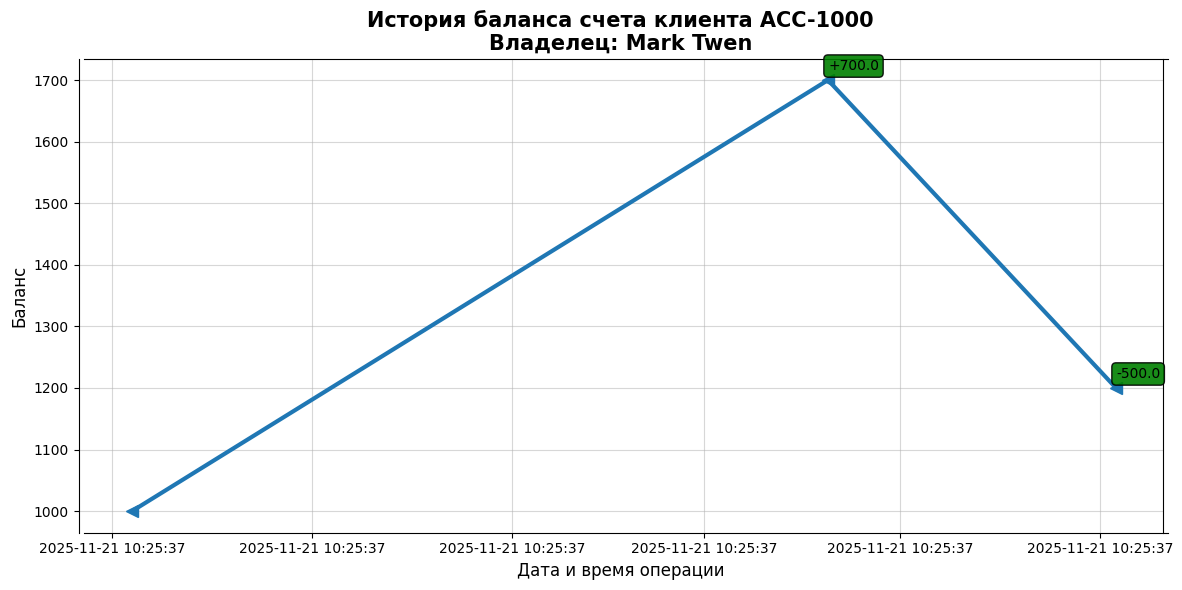

In [3]:
# Создаем базовый класс Account
class Account:
    _account_counter = 1000 # Инициализация приватного атрибута для формирования номера счета
    
    def __init__(self, account_holder, balance=0): # Инициализация атрибутов класса
        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным. Внесите средства на счет!")
        # Вызов ошибки при отрицательном начальном балансе клиента. 
        
        self.holder = account_holder # Формирование имени клиента
        self.account_number = f'ACC-{Account._account_counter}' # Формирование номера счета с учетом приватного параметра
        self._balance = float(balance) # Формирование приватного параметра баланса счета
        self.operations_history = [] # Создание списка с историей операций по счету
        
        # Открытие счета клиента (в историю по операции вносим тип, сумму, дату и время, баланс после операции и статус)
        opening_operation = {
            'type': 'opening',
            'amount': balance,
            'datetime': datetime.datetime.now(),
            'balance_after': self._balance,
            'status': 'success'
        }
        self.operations_history.append(opening_operation)
        
        Account._account_counter += 1 # Формирование следующего номера счета
    
    def deposit(self, amount):
        """Метод для внесения средств на счет"""
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной!")
            # Вывод сообщения об ошибке при попытке внесения отрицательной суммы на счет
        
        operation_datetime = datetime.datetime.now() # Запись даты операции
        
        # Выполним проверку операции deposit на успешность
        try:
            self._balance += amount # пополнение счета на сумму amount
            operation = {
                'type': 'deposit',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'success'
            }
            self.operations_history.append(operation) # Добавление операции в список в случае ее успешного выполнения
        except Exception as e: # При появлении ошибок выводим сообщение об ошибке в историю через str(e)
            operation = {
                'type': 'deposit',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'fail',
                'error': str(e)
            }
            self.operations_history.append(operation)
    
    def withdraw(self, amount): # Реализация метода снятия средств со счета
        """Метод для снятия средств со счета"""
        if amount <= 0:
            raise ValueError("Сумма снятия должна быть положительной") # Вывод ошибки при попытке снятия отрицательной суммы со счета
        
        operation_datetime = datetime.datetime.now() # Запись времени операции
        
        if amount > self._balance:
            # При недостаточной сумме на счете вносим сведения в наш список операций
            operation = {
                'type': 'withdraw',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'fail',
                'error': 'Недостаточно средств'
            }
            self.operations_history.append(operation) # Запись данных об операции в список
        else:
            # В случае успешного снятия списываем деньги со счета
            self._balance -= amount
            operation = {
                'type': 'withdraw',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'success'
            }
            self.operations_history.append(operation) # Запись данных об операции в список
    
    def get_balance(self):
        """Метод, возвращающий текущий баланс счета"""
        return self._balance
    
    def get_history(self):
        """Метод, возвращающий историю операций в виде списка словарей"""
        return self.operations_history.copy()
    
    # Дополнительно создадим метод для форматирования сведений об операциях для последующего графического отображения
    def formating_history(self):
        """Получение отформатированной истории операций"""
        formatted_history = []
        for op in self.operations_history:
            formatted_op = {
                'Тип операции': op['type'],
                'Сумма': op['amount'],
                'Дата и время': op['datetime'].strftime('%Y-%m-%d %H:%M:%S'),
                'Баланс после операции': op['balance_after'],
                'Статус': op['status']
            }
            # Если в словаре по операции присутствует ошибка
            if 'error' in op:
                formatted_op['Ошибка'] = op['error']
            formatted_history.append(formatted_op)
        return formatted_history
    
    # Построим графики, отображающие историю операций со счетом
    def plot_history(self):
        """Метод для построения графиков изменения баланса"""
        # Если данных в истории опепраций нет, выводим сообщение об этом
        if not self.operations_history:
            print("Данные для построения графика отсутствуют!")
            return
        
        # Создание датафрейма на основе истории операций
        df = pd.DataFrame(self.operations_history)
        
        # Фильтрация успешных операций (с учетом операции открытия счета)
        successful_ops = df[df['status'] == 'success']
        
        # При отсутствии достаточного количества успешных операций (0)
        if len(successful_ops) <= 1:
            print("Успешные операции для построения графика отсутствуют!")
            return
        
        # Сортировка операций по времени
        successful_ops = successful_ops.sort_values('datetime')
        
        # Строим график
        plt.figure(figsize=(12, 6)) # Создание координатной оси
        plt.clf()
        plt.plot(successful_ops['datetime'], successful_ops['balance_after'], 
        marker='<', linewidth=3, markersize=8)

        # Настраиваем формат вывода дат по оси X
        date_format = mdates.DateFormatter('%Y-%m-%d %H:%M:%S')
        plt.gca().xaxis.set_major_formatter(date_format)

        # Создание заголовков
        plt.title(f'История баланса счета клиента {self.account_number}\nВладелец: {self.holder}', 
         fontsize=15, fontweight='bold')
        plt.xlabel('Дата и время операции', fontsize=12) # Подписи по оси Х
        plt.ylabel('Баланс', fontsize=12) # Подписи по оси Y
        plt.grid(True, alpha=0.5)
        plt.xticks(rotation=0, fontsize=10)
        plt.tight_layout()
        
        
        # Добавляем аннотации изменений
        for i, (_, row) in enumerate(successful_ops.iterrows()): # используем enumerate для явной индексации элементов successful_ops
            if i > 0:  # Без учета начальной операции
                prev_balance = successful_ops.iloc[i-1]['balance_after']
                current_balance = row['balance_after']
                change = current_balance - prev_balance
                
                if abs(change) > 0:  # Явная аннотация результатов операции при ненулевом изменении
                    plt.annotate(f'{change:+.1f}', 
                               (row['datetime'], row['balance_after']),
                               textcoords="offset pixels", 
                               xytext=(0,10), 
                               ha='left',
                               fontsize=10,
                               bbox=dict(boxstyle="round,pad=0.3", fc="green", alpha=0.9))
        
        plt.show()
        
        # Возвращаем DataFrame для дополнительного анализа
        return df

    def __str__(self):
        return f"Счет {self.account_number}, владелец: {self.holder}, баланс: {self._balance:.2f}" # Вывод информации об объекте класса

    def __repr__(self):
        return f"Account('{self.holder}', {self._balance})"


# Пример работы класса
if __name__ == "__main__":
    # Открытие счета
    print("-- Создание счета --")
    account = Account("Mark Twen", 1000)
    print(account)
    print()
    
    # Тестирование методов
    print("-- Тестирование методов --")
    
    # Успешное пополнение
    print("Пополнение на 700 ед.")
    account.deposit(700)
    print(f"Баланс: {account.get_balance()}")
    
    # Успешное снятие
    print("Снятие 500 ед.")
    account.withdraw(500)
    print(f"Баланс: {account.get_balance()}")
    
    # Неудачная попытка снятия (недостаточно средств)
    print("Попытка снять 2500 ед.")
    account.withdraw(2000)
    print(f"Баланс: {account.get_balance()}")
    
    # Пополнение отрицательной суммой
    try:
        print("Попытка пополнить на -600 ед.")
        account.deposit(-600)
    except ValueError as e:
        print(f"Ошибка: {e}")
    
    print()
    
    # История операций
    print("-- История операций --")
    history = account.formating_history()
    for i, op in enumerate(history):
        print(f"Операция {i+1}: {op}")
    
    print()
    
    # Построение графика истории баланса (если установлены pandas и matplotlib)
    print("-- Построение графика --")
    account.plot_history()

## Задание № 2

-- Тестирование системы банковских счетов --

Оценка функции валидации имени:
   Имя принято!

Создание счетов:
   Счет ACC-1003, владелец: Mark Twen, баланс: 5000.00
   Счет ACC-1004, владелец: Andy Cornell, баланс: 10000.00

Операции на расчетном счете:
  Баланс расчетного счета: 6000.0

Операции на сберегательном счете:
   Баланс сберегательного счета: 0.0

Начисление процентов на сберегательный счет:
   Начислено процентов: 0.00
   Баланс после операции начисления: 0.00

Анализ транзакций:

-- Анализ операций (последние 4 крупных операции) --
Всего операций за рассмотренный: 6
Отфильтровано по приведенным условиям: 4

1. WITHDRAW - 9000.00
   Дата: 2025-11-21 10:51:52
   Баланс после операции: 9000.00
   Статус: fail
   Ошибка: Превышен лимит снятия со сберегательного счета. Ваш максимум: 4500.00

2. WITHDRAW - 9000.00
   Дата: 2025-11-21 10:51:52
   Баланс после операции: 0.00
   Статус: success

3. WITHDRAW - 4000.00
   Дата: 2025-11-21 10:51:52
   Баланс после операции: 9000.00


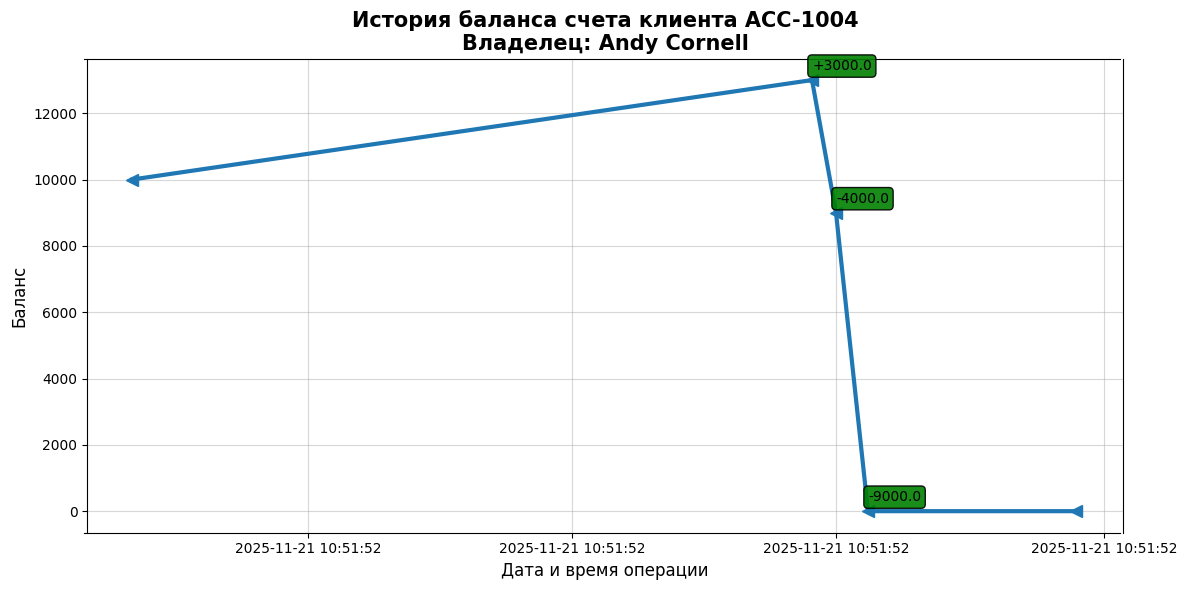

In [9]:
class Account(ABC): # Создадим абстрактный класс для формирования общего интерфейса базового класса
    
    _account_counter = 1000 # Инициализация приватного атрибута для формирования номера счета
    
    def __init__(self, account_holder, balance=0): # Инициализация атрибутов класса
        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным. Внесите средства на счет!")
        # Вызов ошибки при отрицательном начальном балансе клиента. 
        
        self.holder = account_holder # Формирование имени клиента
        self.account_number = f'ACC-{Account._account_counter}' # Формирование номера счета с учетом приватного параметра
        self._balance = float(balance) # Формирование приватного параметра баланса счета
        self.operations_history = [] # Создание списка с историей операций по счету
        
        # Открытие счета клиента (в историю по операции вносим тип, сумму, дату и время, баланс после операции и статус)
        opening_operation = {
            'type': 'opening',
            'amount': balance,
            'datetime': datetime.datetime.now(),
            'balance_after': self._balance,
            'status': 'success'
        }
        self.operations_history.append(opening_operation)
        
        Account._account_counter += 1 # Формирование следующего номера счета
    
    def _validate_holder_name(self, name): # Реализация метода валидации имени пользователя
        """Приватный метод для валидации имени владельца (в формате 'Имя Фамилия')"""
        pattern = r'^[A-ZА-Я][a-zа-я]+\s[A-ZА-Я][a-zа-я]+$'
        if not re.match(pattern, name):
            raise ValueError(
                "Укажите имя владельца в формате 'Имя Фамилия'!"
                "(только кириллица или латиница, первая буква заглавная)"
            )
    
    def _validate_amount(self, amount): # проверка суммы операции
        """Приватный метод для валидации суммы операции"""
        if amount <= 0:
            raise ValueError("Сумма операции должна быть положительной!")
    
    def deposit(self, amount):
        """Метод для внесения средств на счет"""
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной!")
            # Вывод сообщения об ошибке при попытке внесения отрицательной суммы на счет
        
        operation_datetime = datetime.datetime.now() # Запись даты операции
        
        # Выполним проверку операции deposit на успешность
        try:
            self._balance += amount # пополнение счета на сумму amount
            operation = {
                'type': 'deposit',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'success'
            }
            self.operations_history.append(operation) # Добавление операции в список в случае ее успешного выполнения
        except Exception as e: # При появлении ошибок выводим сообщение об ошибке в историю через str(e)
            operation = {
                'type': 'deposit',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'fail',
                'error': str(e)
            }
            self.operations_history.append(operation)
    
    def withdraw(self, amount): # Реализация метода снятия средств со счета
        """Метод для снятия средств со счета"""
        if amount <= 0:
            raise ValueError("Сумма снятия должна быть положительной") # Вывод ошибки при попытке снятия отрицательной суммы со счета
        
        operation_datetime = datetime.datetime.now() # Запись времени операции
        
        if amount > self._balance:
            # При недостаточной сумме на счете вносим сведения в наш список операций
            operation = {
                'type': 'withdraw',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'fail',
                'error': 'Недостаточно средств'
            }
            self.operations_history.append(operation) # Запись данных об операции в список
        else:
            # В случае успешного снятия списываем деньги со счета
            self._balance -= amount
            operation = {
                'type': 'withdraw',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'success'
            }
            self.operations_history.append(operation) # Запись данных об операции в список
    
    def get_balance(self):
        """Метод, возвращающий текущий баланс счета"""
        return self._balance
    
    def get_history(self):
        """Метод, возвращающий историю операций в виде списка словарей"""
        return self.operations_history.copy()
    
    # Дополнительно создадим метод для форматирования сведений об операциях для последующего отображения
    def formating_history(self):
        """Получение отформатированной истории операций"""
        formatted_history = []
        for op in self.operations_history:
            formatted_op = {
                'Тип операции': op['type'],
                'Сумма': op['amount'],
                'Дата и время': op['datetime'].strftime('%Y-%m-%d %H:%M:%S'),
                'Баланс после операции': op['balance_after'],
                'Статус': op['status']
            }
            # Если в словаре по операции присутствует ошибка
            if 'error' in op:
                formatted_op['Ошибка'] = op['error']
            formatted_history.append(formatted_op)
        return formatted_history
    
    def analyze_transactions(self, n=4, min_amount=0, start_date=None, end_date=None):
        """
        Метод для анализа истории транзакций по размеру и дате
        
        n: количество последних крупных операций для вывода
        min_amount: минимальная сумма для фильтрации
        start_date: начальная дата для фильтрации (datetime)
        end_date: конечная дата для фильтрации (datetime)
        """
        # Фильтруем операции по сумме и дате
        filtered_ops = []
        
        for op in self.operations_history:
            # Пропускаем начальную операцию
            if op['type'] == 'opening':
                continue
                
            # Фильтрация по сумме
            if op['amount'] < min_amount:
                continue
                
            # Фильтр по дате
            if start_date and op['datetime'] < start_date:
                continue
            if end_date and op['datetime'] > end_date:
                continue
                
            filtered_ops.append(op)
        
        # Сортировка по сумме и индикация последние n крупных операций
        filtered_ops.sort(key=lambda x: x['amount'], reverse=True)
        large_operations = filtered_ops[:n]
        
        # Сортировка по дате для вывода
        large_operations.sort(key=lambda x: x['datetime'], reverse=True)
        
        print(f"\n-- Анализ операций (последние {n} крупных операции) --")
        print(f"Всего операций за рассмотренный: {len(self.operations_history)}")
        print(f"Отфильтровано по приведенным условиям: {len(large_operations)}")
        
        for i, op in enumerate(large_operations, 1):
            print(f"\n{i}. {op['type'].upper()} - {op['amount']:.2f}")
            print(f"   Дата: {op['datetime'].strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Баланс после операции: {op['balance_after']:.2f}")
            print(f"   Статус: {op['status']}")
            if 'error' in op:
                print(f"   Ошибка: {op['error']}")
        
        return large_operations
    
    def plot_history(self):
        """Метод для построения графиков изменения баланса"""
        # Если данных в истории опепраций нет, выводим сообщение об этом
        if not self.operations_history:
            print("Данные для построения графика отсутствуют!")
            return
        
        # Создание датафрейма на основе истории операций
        df = pd.DataFrame(self.operations_history)
        
        # Фильтрация успешных операций (с учетом операции открытия счета)
        successful_ops = df[df['status'] == 'success']
        
        # При отсутствии достаточного количества успешных операций (0)
        if len(successful_ops) <= 1:
            print("Успешные операции для построения графика отсутствуют!")
            return
        
        # Сортировка операций по времени
        successful_ops = successful_ops.sort_values('datetime')
        
        # Строим график
        plt.figure(figsize=(12, 6)) # Создание координатной оси
        plt.clf()
        plt.plot(successful_ops['datetime'], successful_ops['balance_after'], 
        marker='<', linewidth=3, markersize=8)

        # Настраиваем формат вывода дат по оси X
        date_format = mdates.DateFormatter('%Y-%m-%d %H:%M:%S')
        plt.gca().xaxis.set_major_formatter(date_format)

        # Создание заголовков
        plt.title(f'История баланса счета клиента {self.account_number}\nВладелец: {self.holder}', 
         fontsize=15, fontweight='bold')
        plt.xlabel('Дата и время операции', fontsize=12) # Подписи по оси Х
        plt.ylabel('Баланс', fontsize=12) # Подписи по оси Y
        plt.grid(True, alpha=0.5)
        plt.xticks(rotation=0, fontsize=10)
        plt.tight_layout()
        
        
        # Добавляем аннотации изменений
        for i, (_, row) in enumerate(successful_ops.iterrows()): # используем enumerate для явной индексации элементов successful_ops
            if i > 0:  # Без учета начальной операции
                prev_balance = successful_ops.iloc[i-1]['balance_after']
                current_balance = row['balance_after']
                change = current_balance - prev_balance
                
                if abs(change) > 0:  # Явная аннотация результатов операции при ненулевом изменении
                    plt.annotate(f'{change:+.1f}', 
                               (row['datetime'], row['balance_after']),
                               textcoords="offset pixels", 
                               xytext=(0,10), 
                               ha='left',
                               fontsize=10,
                               bbox=dict(boxstyle="round,pad=0.3", fc="green", alpha=0.9))
        
        plt.show()
        
        # Возвращаем DataFrame для дополнительного анализа
        return df

    def __str__(self):
        return f"Счет {self.account_number}, владелец: {self.holder}, баланс: {self._balance:.2f}" # Вывод информации об объекте класса

    def __repr__(self):
        return f"Account('{self.holder}', {self._balance})"


class CheckingAccount(Account):
    """Реализация класса расчетного счета - наследование от базового класса Account
    (ограничения на операции отсутствуют)"""
    
    def __init__(self, account_holder, balance=0):
        super().__init__(account_holder, balance) # Наследование родительских методов
        self.account_type = "checking"


class SavingsAccount(Account):
    """Сберегательный счет - наследование от Account (начисление процентов и ограничением на снятие)"""
    
    def __init__(self, account_holder, balance=0):
        super().__init__(account_holder, balance)
        self.account_type = "savings"
    
    def use_interest(self, rate):
        """Метод для начисления процентов на остаток"""
        if rate <= 0: # Вывод ошибки при отрицательном начислении процентов
            raise ValueError("Процентная ставка должна быть положительной")
        
        interest_amount = self._balance * (rate / 100)
        operation_datetime = datetime.datetime.now()
        # Проверка корректности операции 
        try:
            self._balance += interest_amount
            operation = {
                'type': 'interest',
                'amount': interest_amount,
                'rate': rate,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'success',
                'account_type': self.account_type
            }
            self.operations_history.append(operation)
            return interest_amount
        except Exception as e: # Запись ошибки операции в историю
            operation = {
                'type': 'interest',
                'amount': interest_amount,
                'rate': rate,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'fail',
                'error': str(e),
                'account_type': self.account_type
            }
            self.operations_history.append(operation)
            return 0
    
    # Переопределяем метод снятия средств со счета
    def withdraw(self, amount):
        """Метод снятия с ограничением 50% от баланса"""
        self._validate_amount(amount)
        
        operation_datetime = datetime.datetime.now()
        
        # Проверяем ограничения сберегательного счета
        max_withdrawal = self._balance * 0.5
        if amount > max_withdrawal:
            operation = {
                'type': 'withdraw',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'fail',
                'error': f'Превышен лимит снятия со сберегательного счета. '
                        f'Ваш максимум: {max_withdrawal:.2f}',
                'account_type': self.account_type
            }
            self.operations_history.append(operation)
            
        
        # Проверка достаточного количества средств на счете
        if amount > self._balance:
            operation = {
                'type': 'withdraw',
                'amount': amount,
                'datetime': operation_datetime,
                'balance_after': self._balance,
                'status': 'fail',
                'error': 'Недостаточно средств',
                'account_type': self.account_type
            }
            self.operations_history.append(operation)
        
        
        # Сценарий при успешном снятии
        self._balance -= amount
        operation = {
            'type': 'withdraw',
            'amount': amount,
            'datetime': operation_datetime,
            'balance_after': self._balance,
            'status': 'success',
            'account_type': self.account_type
        }
        self.operations_history.append(operation)
        


# Демонстрация работы классов
if __name__ == "__main__":
    print("-- Тестирование системы банковских счетов --\n")
    
    # Тестирование валидации имени
    print("Оценка функции валидации имени:")
    try:
        invalid_account = Account("jack ocean петров", 1000)  # только строчные буквы
    except ValueError as e:
        print(f"   Ошибка: {e}")
    
    try:
        invalid_account = Account("john23 mandel", 1000)  # наличие цифр в имени
    except ValueError as e:
        print(f"   Ошибка: {e}")
    
    try:
        invalid_account = Account("Jack Ocean", 1000)  # Корректный ввод
        print("   Имя принято!")
    except ValueError as e:
        print(f"   Ошибка: {e}")
    
    print()
    
    # Инициализация счетов
    print("Создание счетов:")
    checking = CheckingAccount("Mark Twen", 5000)
    savings = SavingsAccount("Andy Cornell", 10000)
    
    print(f"   {checking}")
    print(f"   {savings}")
    print()
    
    # Выполнение операций на расчетном счете
    print("Операции на расчетном счете:")
    checking.deposit(3000)
    checking.withdraw(2000)
    checking.withdraw(15000)
    print(f"  Баланс расчетного счета: {checking.get_balance()}")
    print()
    
    # Операции на сберегательном счете
    print("Операции на сберегательном счете:")
    savings.deposit(3000)
    savings.withdraw(4000)
    savings.withdraw(9000)
    print(f"   Баланс сберегательного счета: {savings.get_balance()}")
    print()
    
    # Начисление процентов
    print("Начисление процентов на сберегательный счет:")
    interest = savings.use_interest(7)
    print(f"   Начислено процентов: {interest:.2f}")
    print(f"   Баланс после операции начисления: {savings.get_balance():.2f}")
    print()
    
    # Анализ транзакций
    print("Анализ транзакций:")
    
    # Анализ крупных операций на сберегательном счете
    savings.analyze_transactions(n=4, min_amount=1000)
    
    # Фильтрация по дате
    end_date = datetime.datetime.now()
    start_date = end_date - datetime.timedelta(hours=24)
    checking.analyze_transactions(n=5, min_amount=500, start_date=start_date, end_date=end_date)
    
    # Показываем историю операций
    print("\nИстория операций сберегательного счета:")
    history = savings.formating_history()
    for i, op in enumerate(history[-4:], 1):  # Последние 4 операции
        print(f"   {i}. {op['Тип операции']} - {op['Сумма']:.2f} | "
              f"Баланс: {op['Баланс после операции']:.2f} | Статус: {op['Статус']}")
    
    # Построение графиков (если установлены библиотеки)
    print("\nПостроение графиков:")
    savings.plot_history()